# Решение после описания задания

# **Задание: Улучшите результаты нейросети CharRnn, используя большую и/или лучше сформированную сеть**

Справка: CharRnn решает задачу многоклассовой классификации имен по национальностям: Ivan - Russia, Nishimora - Japan и т.д. Ваша задача - улучшить решени, используя более продвинутую архитектуру.

•  Настройте гиперпараметры для повышения производительности, такие как: количество эпох, размер батча и скорость обучения (lr).  
•  Протестируйте слои nn.LSTM и nn.GRU  
•  Измените размер слоев, например, увеличив глубину, добавив специальные слои  
•  Объедините несколько этих RNN в сеть более высокого уровня

**Важно!** Ваш написанный код должен быть задокументирован (комментарии в коде или доп. ячейки в местах архитекутры сети).


---


Критерии:

1) Протестирована сеть GRU, написаны выводы по ней (2 балла)  
2) Протестирована сеть LSTM, написаны выводы по ней (Примечание: посмотрите, что возвращает nn.LSTM: возможно, что-то лишнее, что нужно будет учесть в функции forward вашей НС) (3 балла)  
3) Протестирована глубокая нейросеть: несколько **рекуррентных слоев** описана мотивировка выбора количества слоев и ее архитектуры (2 балла)  
4) Протестирована глубокая нейросеть: несколько **рекуррентных и несколько линейных слоев** описана мотивировка выбора количества слоев и ее архитектуры (2 балла)
5) Функция train изменена так, чтобы сохранять в каждую эпоху ошибки по трейн **и тест** выборках. Сделана функция визуализации ошибок на трейн/тест выборках, сделаны выводы: есть ли переобучение у моделей из пунктов 2, 3, 4 на основе этих графиков (1 балл)


---



**Примечание! Используйте GPU, снизьте количество эпох, если обучение занимает слишком много времени: если ваша модель работает, то сделайте выводы об ее эффективности по первым нескольким эпохам, снижение оценки за это не будет. Но эта опция только для действительно "долгих" в обучении нейросетей.**

In [19]:
import torch

device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

torch.set_default_device(device)
print(f"Используем {torch.get_default_device()}")


Используем cpu


In [20]:
!unzip -o data.zip

Archive:  data.zip
  inflating: data/eng-fra.txt        
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Italian.txt  
  inflating: data/names/Japanese.txt  
  inflating: data/names/Korean.txt   
  inflating: data/names/Polish.txt   
  inflating: data/names/Portuguese.txt  
  inflating: data/names/Russian.txt  
  inflating: data/names/Scottish.txt  
  inflating: data/names/Spanish.txt  
  inflating: data/names/Vietnamese.txt  


Подготовка данных
==================


In [21]:
import string
import unicodedata

allowed_characters = string.ascii_letters + " .,;'"
n_letters = len(allowed_characters)

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

Для начала переведем все на Ascii, пример ниже:


In [22]:
print (f"Конвертация 'Ślusàrski' в {unicodeToAscii('Ślusàrski')}")

Конвертация 'Ślusàrski' в Slusarski


Переводим имена в тензоры
==========================

Теперь, когда у нас есть все имена, нам нужно преобразовать их в Тензоры, чтобы иметь возможность их использовать.

Для представления одной буквы мы используем "one-hot вектор" размера <1 x n_letters>. One-hot вектор заполнен нулями, за исключением единицы в индексе текущей буквы, например, "b" = <0 1 0 0 0 ...>.

Чтобы создать слово, мы объединяем несколько таких векторов в 2D-матрицу <длина_строки x 1 x n_letters>.

Эта дополнительная размерность 1 нужна, потому что PyTorch предполагает, что все находится в батчах - здесь мы просто используем размер батча, равный 1.

In [23]:
def letterToIndex(letter):
    return allowed_characters.find(letter)

def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

Пример использования `lineToTensor()` для разных строк


In [24]:
print (f"Символ 'a' переходит в тензор {lineToTensor('a')}")
print (f"Строка 'Ahn' переходит в тензор {lineToTensor('Ahn')}") #notice 'A' sets the 27th index to 1

Символ 'a' переходит в тензор tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]]])
Строка 'Ahn' переходит в тензор tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [25]:
from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset



class NamesDataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.load_time = time.localtime
        labels_set = set()

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor(name))
                self.labels.append(label)

        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_label = self.labels[idx]
        data_tensor = self.data_tensors[idx]
        label_tensor = self.labels_tensors[idx]

        return label_tensor, data_tensor, data_label, data_item

Загружаем примеры в `NamesDataset`


In [26]:
alldata = NamesDataset("data/names")
print(f"загрузили {len(alldata)} примеров имен")
print(f"Пример имени: {alldata[0]}")

загрузили 20074 примеров имен
Пример имени: (tensor([15]), tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]]]), 'Czech', 'Abl')


Конвертируем в датасет используя  `torch.utils.data`


In [28]:
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator(device=device).manual_seed(2024))

print(f"train примеры = {len(train_set)}, validation примеры = {len(test_set)}")


train примеры = 17063, validation примеры = 3011


Всего  **20074** примеров


Задание 0. Создаем базовую нейросеть для классификации имен по национальностям (задание здесь)
===================


In [29]:
import torch.nn as nn
import torch.nn.functional as F

# Пример сети, которая бует решать задачу классификации имен по национальностям
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size) # Используем Обычную RNN
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1) # Используем функцию ошибки для многоклассовой классификации

    def forward(self, line_tensor):
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.fc(hidden[0])
        output = self.softmax(output)

        return output

# Создайте аналогичный класс, изменив его архитектуру по критериям, описанным в начале блокнота и обучите его, используя функцию ниже. Протестируйте каждую модель.
## Подпишите все ваши блоки кода: к какому заданию относятся, задокументируйте основные моменты, как в примере выше.

In [30]:
n_hidden = 128
rnn = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
print(rnn)

CharRNN(
  (rnn): RNN(57, 128)
  (fc): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


После этого мы можем передать наш Тензор в RNN, чтобы получить предсказанный результат. Впоследствии мы используем вспомогательную функцию, label_from_output, чтобы получить текстовую метку для класса.


In [31]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = lineToTensor('Albert')
output = rnn(input)
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.8164, -2.8599, -2.9507, -2.8923, -2.7738, -2.9543, -2.7968, -3.0255,
         -2.9196, -3.0152, -2.8452, -2.8817, -2.8883, -2.9287, -2.8320, -2.9816,
         -2.8270, -2.8826]], grad_fn=<LogSoftmaxBackward0>)
('Greek', 4)


*Обучение*
========


Обучение нейросети (здесь задание)
====================

Теперь, чтобы обучить эту сеть, достаточно показать ей кучу примеров, позволить ей делать предположения и сообщать, если она не права.

Мы делаем это, определя функцию train(), которая обучает модель на заданном наборе данных, используя мини-батчи. RNN (рекуррентные нейронные сети) обучаются аналогично другим сетям; поэтому для полноты мы включаем здесь метод пакетного обучения. Цикл (for i in batch) вычисляет потери для каждого элемента в пакете перед корректировкой весов. Эта операция повторяется до достижения количества эпох.


In [32]:
import random
import numpy as np

def train(rnn, training_data, n_epoch = 10, n_batch_size = 64, report_every = 50, learning_rate = 0.2, criterion = nn.NLLLoss()):
    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    start = time.time()
    print(f"Обучаем с количеством сэмплов n = {len(training_data)}")

    for iter in range(1, n_epoch + 1):
        rnn.zero_grad()
        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches) //n_batch_size )

        for idx, batch in enumerate(batches):
            batch_loss = 0
            for i in batch:
                (label_tensor, text_tensor, label, text) = training_data[i]
                output = rnn.forward(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            batch_loss.backward()
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        all_losses.append(current_loss / len(batches) )
        if iter % report_every == 0:
            print(f"{iter} ({iter / n_epoch:.0%}): \t Средняя ошибка по батчу = {all_losses[-1]}")
        current_loss = 0

    return all_losses

Теперь мы можем обучить набор данных с мини-батчами в течение указанного количества эпох. Количество эпох для этого примера уменьшено для ускорения сборки. Вы можете получить лучшие результаты с другими параметрами.


In [33]:
start = time.time()
all_losses = train(rnn, train_set, n_epoch=27, learning_rate=0.15, report_every=5)
end = time.time()
print(f"обучение заняло {end-start} секунд")

Обучаем с количеством сэмплов n = 17063
5 (19%): 	 Средняя ошибка по батчу = 0.8970278317715268
10 (37%): 	 Средняя ошибка по батчу = 0.6989605941115397
15 (56%): 	 Средняя ошибка по батчу = 0.5761457308066795
20 (74%): 	 Средняя ошибка по батчу = 0.49518524727392504
25 (93%): 	 Средняя ошибка по батчу = 0.43854239067895484
обучение заняло 131.62774300575256 секунд


Визуализируем результаты
====================


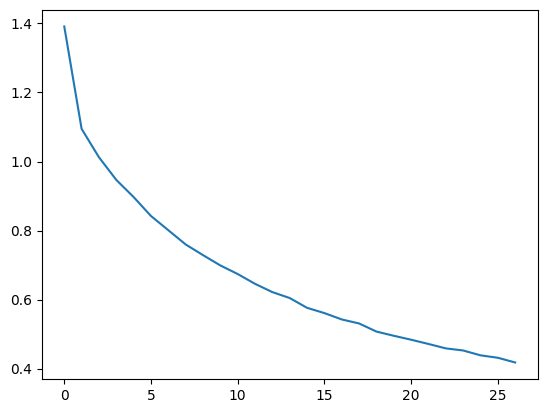

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

Измеряем эффективность модели
======================

Чтобы увидеть, насколько хорошо сеть работает с разными категориями, мы создадим матрицу ошибок, указывающую для каждого фактического языка (строки), какой язык сеть угадывает (столбцы). Чтобы вычислить матрицу ошибок, через сеть прогоняется набор образцов с помощью функции evaluate(), которая аналогична функции train(), за исключением отсутствия обратного распространения (backprop).


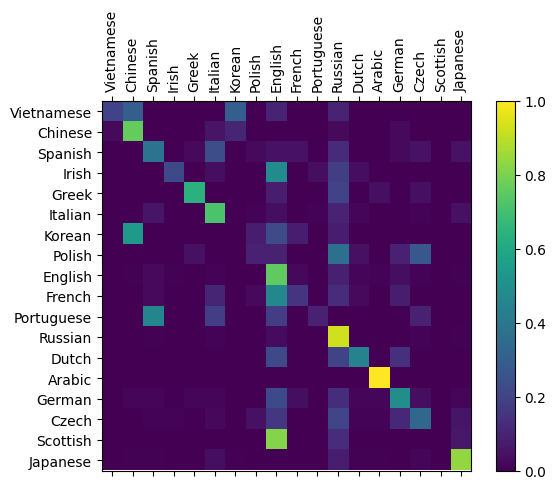

In [39]:
def evaluate(rnn, testing_data, classes):
    confusion = torch.zeros(len(classes), len(classes))

    rnn.eval()
    with torch.no_grad():
        for i in range(len(testing_data)):
            (label_tensor, text_tensor, label, text) = testing_data[i]
            output = rnn(text_tensor)
            guess, guess_i = label_from_output(output, classes)
            label_i = classes.index(label)
            confusion[label_i][guess_i] += 1

    for i in range(len(classes)):
        denom = confusion[i].sum()
        if denom > 0:
            confusion[i] = confusion[i] / denom

    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy())
    fig.colorbar(cax)

    ax.set_xticks(np.arange(len(classes)), labels=classes, rotation=90)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()



evaluate(rnn, test_set, classes=alldata.labels_uniq)

# Решение (Максимов Павел)

## Критерий 5 (часть 1)
## Модификация функции train (сохранение средней train/test-ошибок + функция визуализации для итогов)

In [40]:
import random
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


@torch.no_grad()
def eval_loss(model, data, criterion=nn.NLLLoss()):
    #Считаем среднеюю ошибку
    model.eval()
    total = 0.0
    for i in range(len(data)):
        (label_tensor, text_tensor, label, text) = data[i]
        output = model(text_tensor)
        total += criterion(output, label_tensor).item()
    return total / len(data)


@torch.no_grad()
def accuracy(model, data, classes):
    #Считаем долю верно классифицированных имён
    model.eval()
    correct = 0
    for i in range(len(data)):
        (label_tensor, text_tensor, label, text) = data[i]
        output = model(text_tensor)
        guess, guess_i = label_from_output(output, classes)
        if guess == label:
            correct += 1
    return correct / len(data)


def train(rnn, training_data, testing_data=None, n_epoch=10, n_batch_size=64,
          report_every=1, learning_rate=0.15, criterion=nn.NLLLoss()):
    train_losses = []
    test_losses = []
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    start = time.time()
    print(f"Обучаем модель {rnn.__class__.__name__}, n = {len(training_data)} примеров")

    for epoch in range(1, n_epoch + 1):
        rnn.train()
        current_loss = 0.0

        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches) // n_batch_size)

        for idx, batch in enumerate(batches):
            batch_loss = 0
            for i in batch:
                (label_tensor, text_tensor, label, text) = training_data[i]
                output = rnn(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            batch_loss.backward()
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        train_losses.append(current_loss / len(batches))

        if testing_data is not None:
            test_losses.append(eval_loss(rnn, testing_data, criterion))

        if epoch % report_every == 0:
            msg = f"эпоха {epoch:>2}/{n_epoch}: train loss = {train_losses[-1]:.4f}"
            if testing_data is not None:
                msg += f" | test loss = {test_losses[-1]:.4f}"
            print(msg)

    print(f"обучение заняло {time.time() - start:.1f} сек")
    return train_losses, test_losses


def plot_losses(train_losses, test_losses=None, title="Ошибка на train/test"):
    #Визуализация кривых ошибки на train и test
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='train')
    if test_losses:
        plt.plot(range(1, len(test_losses) + 1), test_losses, marker='s', label='test')
    plt.xlabel('эпоха')
    plt.ylabel('средняя ошибка (NLL)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## Критерий 1
## Сеть на GRU

In [41]:
class CharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        gru_out, hidden = self.gru(line_tensor)
        output = self.fc(hidden[-1])
        output = self.softmax(output)
        return output

CharGRU(
  (gru): GRU(57, 128)
  (fc): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)
Обучаем модель CharGRU, n = 17063 примеров
эпоха  1/15: train loss = 1.4793 | test loss = 1.2601
эпоха  2/15: train loss = 1.1278 | test loss = 1.0898
эпоха  3/15: train loss = 0.9943 | test loss = 0.9759
эпоха  4/15: train loss = 0.9201 | test loss = 0.8461
эпоха  5/15: train loss = 0.8584 | test loss = 0.8097
эпоха  6/15: train loss = 0.7940 | test loss = 0.7799
эпоха  7/15: train loss = 0.7454 | test loss = 0.7427
эпоха  8/15: train loss = 0.6968 | test loss = 0.6532
эпоха  9/15: train loss = 0.6554 | test loss = 0.6526
эпоха 10/15: train loss = 0.6169 | test loss = 0.6252
эпоха 11/15: train loss = 0.5906 | test loss = 0.5897
эпоха 12/15: train loss = 0.5591 | test loss = 0.5609
эпоха 13/15: train loss = 0.5312 | test loss = 0.5880
эпоха 14/15: train loss = 0.5047 | test loss = 0.5747
эпоха 15/15: train loss = 0.4777 | test loss = 0.5452
обучение заняло 273.0 с

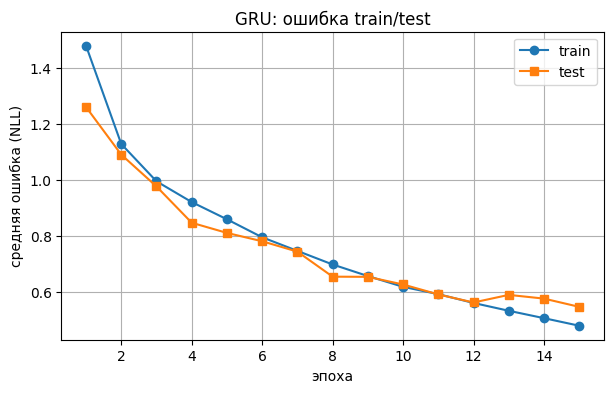

GRU accuracy на train = 0.865
GRU accuracy на test  = 0.838


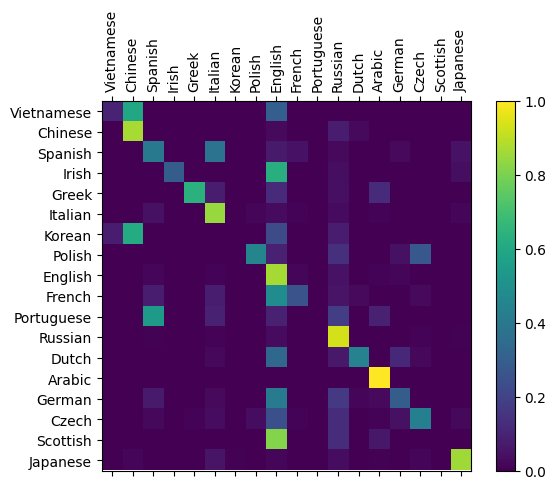

In [45]:
#Обучение и оценка GRU
n_hidden = 128
gru = CharGRU(n_letters, n_hidden, len(alldata.labels_uniq))
print(gru)

gru_train_losses, gru_test_losses = train(
    gru, train_set, testing_data=test_set, n_epoch=15, learning_rate=0.15
)

plot_losses(gru_train_losses, gru_test_losses, title="GRU: ошибка train/test")
print(f"GRU accuracy на train = {accuracy(gru, train_set, alldata.labels_uniq):.3f}")
print(f"GRU accuracy на test  = {accuracy(gru, test_set,  alldata.labels_uniq):.3f}")
evaluate(gru, test_set, classes=alldata.labels_uniq)

## Выводы по GRU

* Обучается стабильно, ошибка на train монотонно падает, на test в целом тоже, за исключением небольших выбросов на последних эпохах, но в пределах нормы. Из чего можно сделать вывод что сильного переобучения нет.

* По сравнению с базовой RNN GRU даёт более низкую ошибку и более высокую точность при том же hidden_size.

* Как и раньше уязвивимым местом остаются редкие национальности (можно посмотреть по матрице ошибок), они классифицируются хуже.

## Критерий 2
## Сеть на LSTM

In [46]:
class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        #Не учитываем состояние ячейки, которое является лишним
        lstm_out, (hidden, cell) = self.lstm(line_tensor)
        output = self.fc(hidden[-1])
        output = self.softmax(output)
        return output

CharLSTM(
  (lstm): LSTM(57, 128)
  (fc): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)
Обучаем модель CharLSTM, n = 17063 примеров
эпоха  1/15: train loss = 1.5829 | test loss = 1.4183
эпоха  2/15: train loss = 1.2374 | test loss = 1.0794
эпоха  3/15: train loss = 1.0755 | test loss = 0.9560
эпоха  4/15: train loss = 0.9796 | test loss = 0.8959
эпоха  5/15: train loss = 0.9135 | test loss = 0.8374
эпоха  6/15: train loss = 0.8494 | test loss = 0.7986
эпоха  7/15: train loss = 0.8030 | test loss = 0.7605
эпоха  8/15: train loss = 0.7555 | test loss = 0.6995
эпоха  9/15: train loss = 0.7122 | test loss = 0.7085
эпоха 10/15: train loss = 0.6720 | test loss = 0.6919
эпоха 11/15: train loss = 0.6388 | test loss = 0.6411
эпоха 12/15: train loss = 0.6101 | test loss = 0.6121
эпоха 13/15: train loss = 0.5812 | test loss = 0.6038
эпоха 14/15: train loss = 0.5562 | test loss = 0.6092
эпоха 15/15: train loss = 0.5318 | test loss = 0.5869
обучение заняло 291

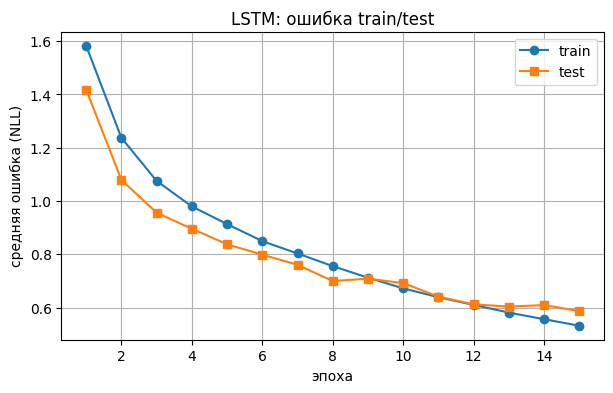

LSTM accuracy на train = 0.846
LSTM accuracy на test  = 0.819


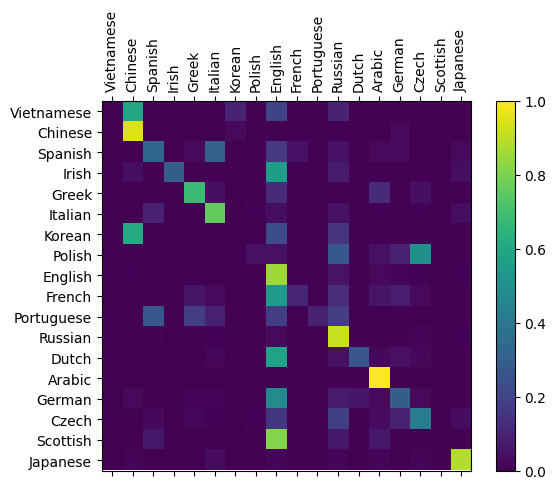

In [47]:
#Обучение и оценка LSTM
lstm = CharLSTM(n_letters, n_hidden, len(alldata.labels_uniq))
print(lstm)

lstm_train_losses, lstm_test_losses = train(
    lstm, train_set, testing_data=test_set, n_epoch=15, learning_rate=0.15
)

plot_losses(lstm_train_losses, lstm_test_losses, title="LSTM: ошибка train/test")
print(f"LSTM accuracy на train = {accuracy(lstm, train_set, alldata.labels_uniq):.3f}")
print(f"LSTM accuracy на test  = {accuracy(lstm, test_set,  alldata.labels_uniq):.3f}")
evaluate(lstm, test_set, classes=alldata.labels_uniq)

## Выводы по LSTM

* Обучаение достаточно стабильное, как и y GRU под конец было несколько отклонений, но общая монотонность сохраняется, сильного переобучения нет.

* По качеству LSTM оказался чуть хуже чем GRU, но всё ещё лучше RNN. 

* Из-за большего числа обучаемых параметров модель училась чуть дольше чем GRU.

## Критерий 3
## Глубокая сеть (2 рекуррентных слоя)

**Мотивировка архитектуры:** 

Решил взять 2 LSTM слоя, чтобы по сравнению с предидущим пунктом изменить только глубину сети и увидеть чисто эффект добавления второго рекуррентного слоя. (Аналогично сделаю ниже 2 слоя GRU, интересно посмотреть на сравнении между ними)

Только 2, так как имена короткие и смысла в очень глубоком стеке не будет, просто возникнет переобучение, да и обучение займёт достаточно много времени. 

Dropout будет 0.2, как примерно стандартное значение

In [48]:
#Стек из 2-х слоёв LSTM
class DeepCharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.2):
        super(DeepCharLSTM, self).__init__()
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers=num_layers, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        lstm_out, (hidden, cell) = self.lstm(line_tensor)
        output = self.fc(hidden[-1])
        output = self.softmax(output)
        return output

In [49]:
#Стек из 2-х слоёв GRU
class DeepCharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.2):
        super(DeepCharGRU, self).__init__()
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size,
                          num_layers=num_layers, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        gru_out, hidden = self.gru(line_tensor)
        output = self.fc(hidden[-1])
        output = self.softmax(output)
        return output

DeepCharLSTM(
  (lstm): LSTM(57, 128, num_layers=2, dropout=0.2)
  (fc): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)
Обучаем модель DeepCharLSTM, n = 17063 примеров
эпоха  1/15: train loss = 1.7730 | test loss = 1.5962
эпоха  2/15: train loss = 1.4633 | test loss = 1.3108
эпоха  3/15: train loss = 1.2855 | test loss = 1.1985
эпоха  4/15: train loss = 1.1557 | test loss = 1.0559
эпоха  5/15: train loss = 1.0601 | test loss = 1.0170
эпоха  6/15: train loss = 0.9967 | test loss = 0.9076
эпоха  7/15: train loss = 0.9358 | test loss = 0.8952
эпоха  8/15: train loss = 0.8876 | test loss = 0.9111
эпоха  9/15: train loss = 0.8414 | test loss = 0.7887
эпоха 10/15: train loss = 0.8022 | test loss = 0.8138
эпоха 11/15: train loss = 0.7637 | test loss = 0.7838
эпоха 12/15: train loss = 0.7259 | test loss = 0.7025
эпоха 13/15: train loss = 0.6947 | test loss = 0.7198
эпоха 14/15: train loss = 0.6612 | test loss = 0.6468
эпоха 15/15: train loss = 0.6302 | tes

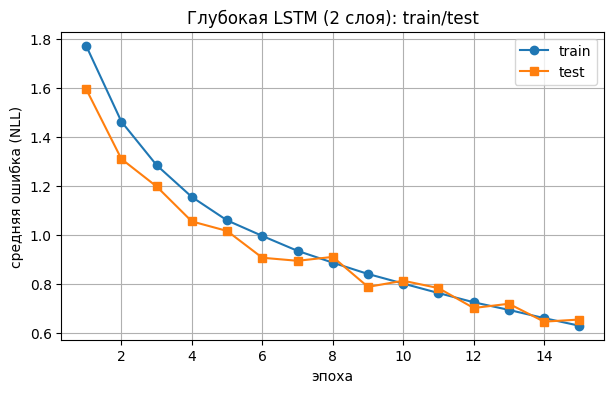

DeepLSTM accuracy на train = 0.806
DeepLSTM accuracy на test  = 0.805


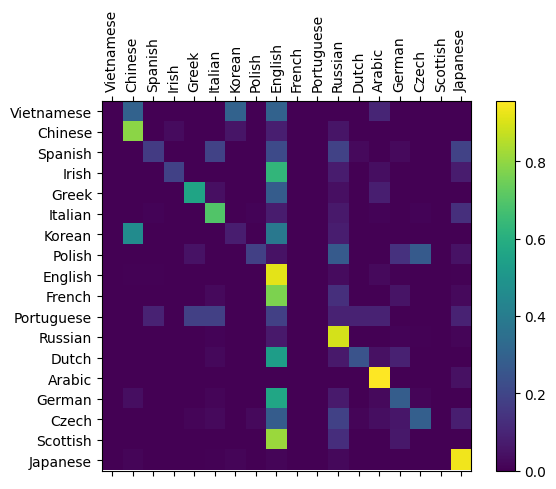

In [50]:
#Обучение и оценка стека LSTM
deep_lstm = DeepCharLSTM(n_letters, n_hidden, len(alldata.labels_uniq),
                         num_layers=2, dropout=0.2) 
print(deep_lstm)

deep_train_losses, deep_test_losses = train(
    deep_lstm, train_set, testing_data=test_set, n_epoch=15, learning_rate=0.15
)

plot_losses(deep_train_losses, deep_test_losses, title="Глубокая LSTM (2 слоя): train/test")
print(f"DeepLSTM accuracy на train = {accuracy(deep_lstm, train_set, alldata.labels_uniq):.3f}")
print(f"DeepLSTM accuracy на test  = {accuracy(deep_lstm, test_set,  alldata.labels_uniq):.3f}")
evaluate(deep_lstm, test_set, classes=alldata.labels_uniq)

DeepCharGRU(
  (gru): GRU(57, 128, num_layers=2, dropout=0.2)
  (fc): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)
Обучаем модель DeepCharGRU, n = 17063 примеров
эпоха  1/15: train loss = 1.6302 | test loss = 1.3526
эпоха  2/15: train loss = 1.2473 | test loss = 1.0542
эпоха  3/15: train loss = 1.0790 | test loss = 1.0039
эпоха  4/15: train loss = 0.9797 | test loss = 0.9201
эпоха  5/15: train loss = 0.9145 | test loss = 0.8254
эпоха  6/15: train loss = 0.8471 | test loss = 0.7979
эпоха  7/15: train loss = 0.7875 | test loss = 0.7317
эпоха  8/15: train loss = 0.7363 | test loss = 0.7362
эпоха  9/15: train loss = 0.6896 | test loss = 0.6533
эпоха 10/15: train loss = 0.6494 | test loss = 0.6240
эпоха 11/15: train loss = 0.6162 | test loss = 0.6144
эпоха 12/15: train loss = 0.5833 | test loss = 0.6129
эпоха 13/15: train loss = 0.5518 | test loss = 0.5796
эпоха 14/15: train loss = 0.5208 | test loss = 0.5691
эпоха 15/15: train loss = 0.4940 | test lo

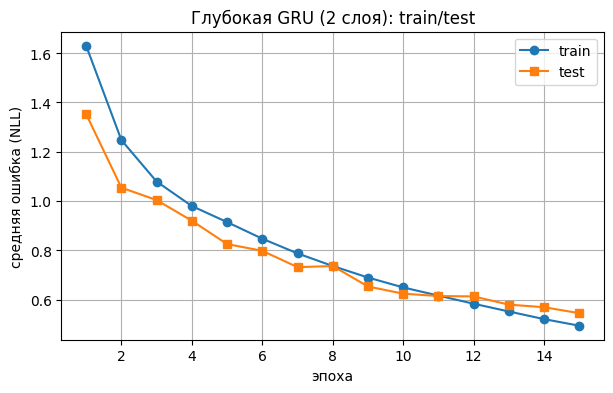

DeepGRU accuracy на train = 0.870
DeepGRU accuracy на test  = 0.833


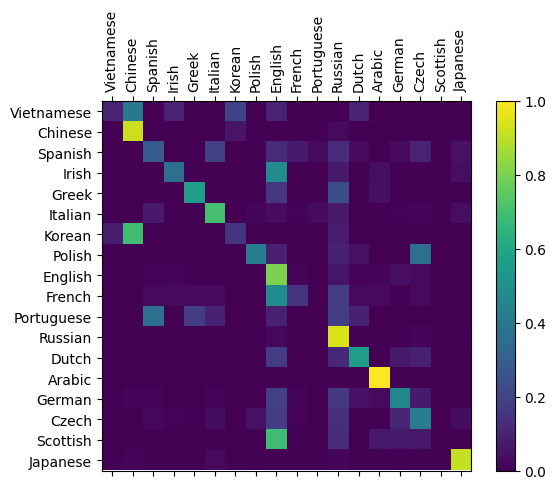

In [51]:
#Обучение и оценка стека GRU
deep_gru = DeepCharGRU(n_letters, n_hidden, len(alldata.labels_uniq),
                       num_layers=2, dropout=0.2)
print(deep_gru)

deep_gru_train_losses, deep_gru_test_losses = train(
    deep_gru, train_set, testing_data=test_set, n_epoch=15, learning_rate=0.15
)

plot_losses(deep_gru_train_losses, deep_gru_test_losses, title="Глубокая GRU (2 слоя): train/test")
print(f"DeepGRU accuracy на train = {accuracy(deep_gru, train_set, alldata.labels_uniq):.3f}")
print(f"DeepGRU accuracy на test  = {accuracy(deep_gru, test_set,  alldata.labels_uniq):.3f}")
evaluate(deep_gru, test_set, classes=alldata.labels_uniq)

## Выводы по глубокой рекуррентной сети

* Как у LSTM, так и у GRU два рекуррентных слоя позволяют строить иерархию признаков и обычно дают ошибку на train ниже, чем однослойные модели. Однако из-за большего числа параметров и dropout сеть учится медленнее за эпоху и может потребовать чуть больше эпох. (однако на GRU результат вышел схожим с однослойной версией за то же количество эпох)

* Делать стек глубже (3+ слоёв) для таких коротких строк нецелесообразно: рост качества небольшой, а риск переобучения и время обучения растут. Для следующего пункта будем использовать аналогично 2 слоя

* Сравнивая GRU и LSTM: GRU дал значительно лучший результат ещё и за меньшее время, но можно наблюдать признаки начала небольшого ереобучения в конце, хоть и в пределах нормы.

## Критерий 4
## Глубокая сеть (2 рекуррентных GRU + MLP классификатор из 3-х линейных слоёв)

**Мотивировка архитектуры:**

В рекуррентной части взял 2 слоя GRU, а не LSTM, так как в прошлом пункте GRU у меня обучился лучше, так что «голову» из линейных слоёв строю именно над ним.

Основная идея такая: GRU сжимает всё имя в один вектор. Если этот вектор сразу подать в один линейный слой, то классификатор сможет лишь провести прямые границы между национальностями. А близкие национальности так нормально разделить не получится. Поэтому ставлю небольшой MLP из 3-х линейных слоёв с ReLU между ними.

* Первый слой (128 -> 128) просто перемешивает и пересобирает признаки, пришедшие из GRU, не теряя информации
* После него ReLU и Dropout

* Второй слой (128 -> 64) заставляет сеть оставить только самые полезные признаки и постепенно вести размерность к числу классов

* Третий слой (64 -> 18) выдаёт оценку по каждой из 18 национальностей.

Больше слоёв или шире делать не стал, так как датасет маленький, имена короткие и это дало бы только переобучение и более долгое обучение без заметного прироста.

**Небольшой доп после первых тестов история которых в тетрадке не отображена:**

Пробовал изначально 15 эпох и Dropout=0.3 (чуть увеличил чтобы избежать возможного переобучения), результат был плохой, сеть схлопывалась к нескольким частотным классам, диагональ почти отсутствовала. После решил выставить обрано 0.2 и увеличить количество эпох до 23

In [55]:
#Глубокая сеть GRU + MLP (2 рекуррентных GRU + классификатор из 3-х линейных слоёв)
class DeepCharGRU_MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.2):
        super(DeepCharGRU_MLP, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size,
                          num_layers=num_layers, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, output_size),
        )
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        gru_out, hidden = self.gru(line_tensor)
        features = hidden[-1]
        output = self.classifier(features)
        output = self.softmax(output)
        return output

DeepCharGRU_MLP(
  (gru): GRU(57, 128, num_layers=2, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=18, bias=True)
  )
  (softmax): LogSoftmax(dim=1)
)
Обучаем модель DeepCharGRU_MLP, n = 17063 примеров
эпоха  1/23: train loss = 1.7269 | test loss = 1.5485
эпоха  2/23: train loss = 1.4588 | test loss = 1.3734
эпоха  3/23: train loss = 1.2514 | test loss = 1.1928
эпоха  4/23: train loss = 1.1460 | test loss = 1.0802
эпоха  5/23: train loss = 1.0807 | test loss = 0.9705
эпоха  6/23: train loss = 1.0206 | test loss = 0.9191
эпоха  7/23: train loss = 0.9687 | test loss = 0.9263
эпоха  8/23: train loss = 0.9181 | test loss = 0.8442
эпоха  9/23: train loss = 0.8663 | test loss = 0.8270
эпоха 10/23: train loss = 0.8315 | test loss = 0.7588
эпоха 11/23: train loss 

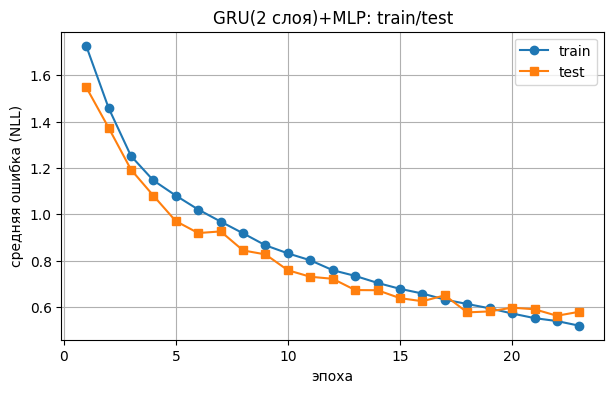

GRU+MLP accuracy на train = 0.857
GRU+MLP accuracy на test  = 0.829


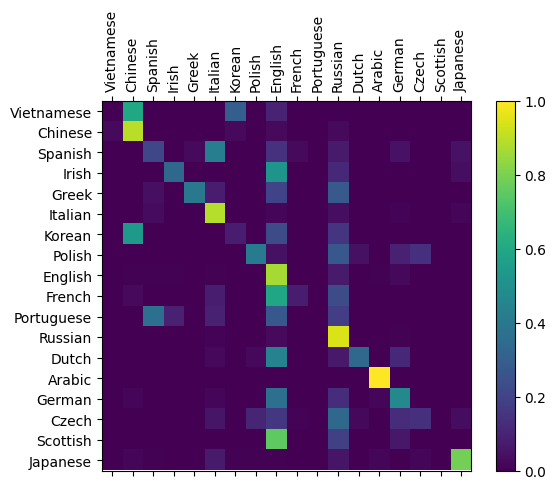

In [56]:
#Обучение и оценка сети GRU + MLP
deep_mlp = DeepCharGRU_MLP(n_letters, n_hidden, len(alldata.labels_uniq),
                           num_layers=2, dropout=0.2)
print(deep_mlp)

mlp_train_losses, mlp_test_losses = train(
    deep_mlp, train_set, testing_data=test_set, n_epoch=23, learning_rate=0.15
)

plot_losses(mlp_train_losses, mlp_test_losses, title="GRU(2 слоя)+MLP: train/test")
print(f"GRU+MLP accuracy на train = {accuracy(deep_mlp, train_set, alldata.labels_uniq):.3f}")
print(f"GRU+MLP accuracy на test  = {accuracy(deep_mlp, test_set,  alldata.labels_uniq):.3f}")
evaluate(deep_mlp, test_set, classes=alldata.labels_uniq)

## Выводы по глубокой сети GRU + MLP

* После увеличения числа эпох до 23 и возвращения Dropout до 0.2 картина изменилась кардинально. На матрице ошибок появилась чёткая диагональ почти по всем классам, остаточные путаницы носят осмысленный лингвистический характер.

* Заметного переобучения нет, лишь после примерно 18-ой эпохи есть намёки на начало переобучения, при это ошибка по test скорее выходит на плато, а не растёт.

* По итогу для этой задачи MLP поверх GRU работоспособна и даёт качество, сравнимое с глубоким GRU (но разница невелика). С учётом времени затаченным на обучение, просто глубокий GRU смотрится значительно выигрышнее.

## Критерий 5
## Сравнение моделей (выводы о переобучении)

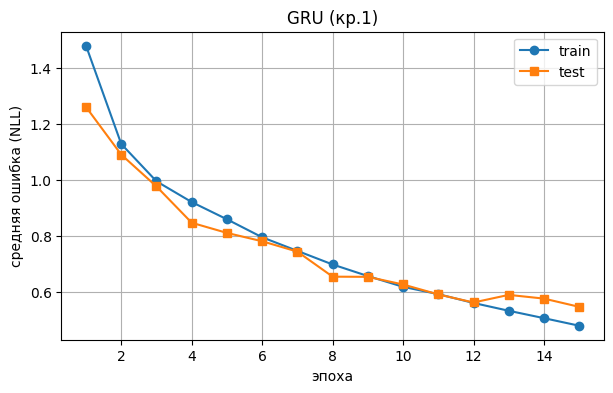

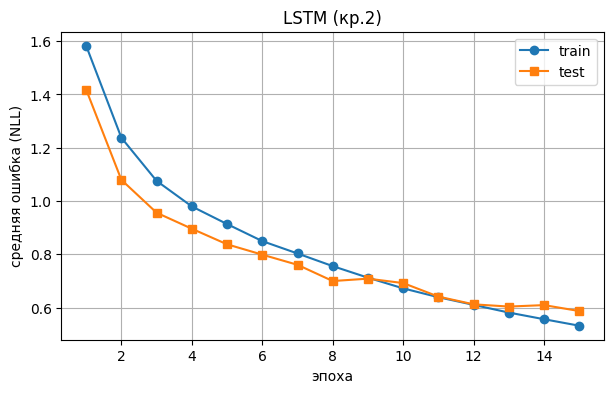

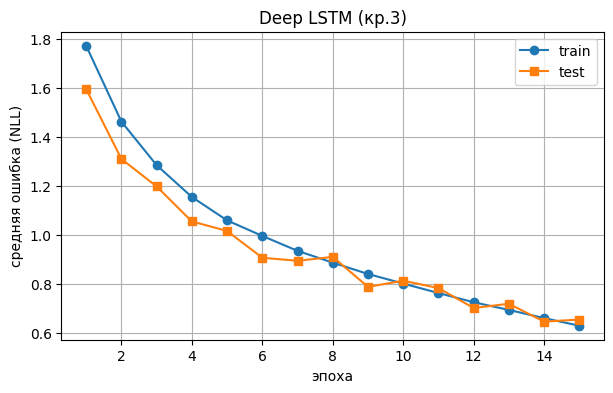

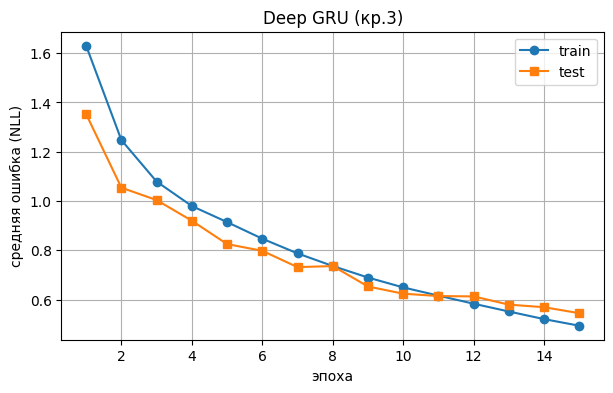

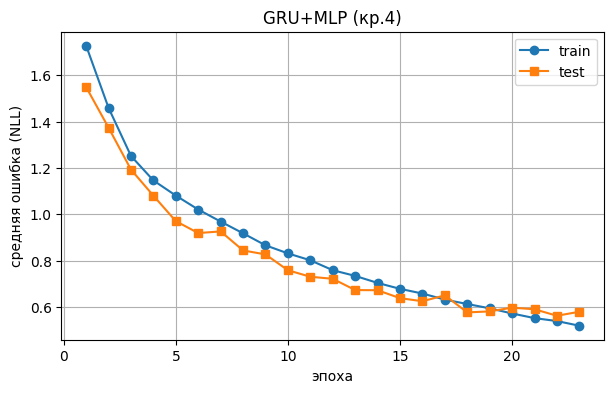

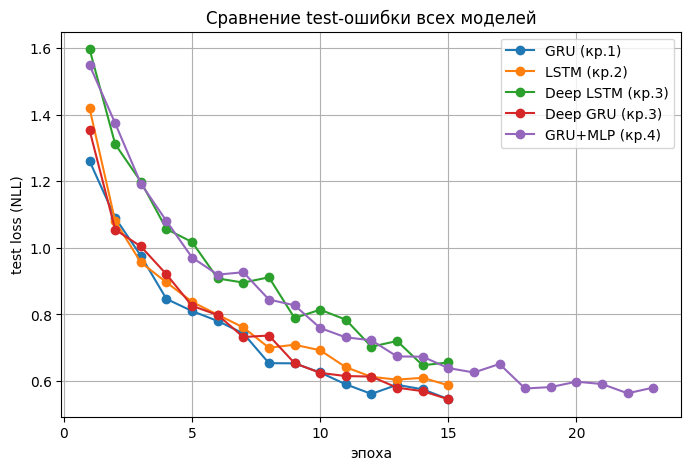

In [60]:
models_losses = {
    "GRU (кр.1)":            (gru_train_losses,      gru_test_losses),
    "LSTM (кр.2)":           (lstm_train_losses,     lstm_test_losses),
    "Deep LSTM (кр.3)":      (deep_train_losses,     deep_test_losses),
    "Deep GRU (кр.3)":       (deep_gru_train_losses, deep_gru_test_losses),
    "GRU+MLP (кр.4)":        (mlp_train_losses,      mlp_test_losses),
}

for name, (tr, te) in models_losses.items():
    plot_losses(tr, te, title=name)

plt.figure(figsize=(8, 5))
for name, (tr, te) in models_losses.items():
    plt.plot(range(1, len(te) + 1), te, marker='o', label=name)
plt.xlabel('эпоха'); plt.ylabel('test loss (NLL)')
plt.title('Сравнение test-ошибки всех моделей')
plt.legend(); plt.grid(True)
plt.show()

## Итоговые выводы о переобучении и о сравнении между моделями

Ранее я уже писал свои размышления по этому поводу в промежуточных итогах, но суммаризируем ещё раз всё вместе:

* Все модели обучаются и выходят на плато, а не растут. К концу обучения test-ошибка у всех опускается в коридор ~0.54-0.65 и выравнивается. Это значит, что выраженного переобучения ни у одной модели на показанном диапазоне эпох нет.

* Семейство GRU стабильно лучше семейства LSTM. Синяя (GRU) и красная (Deep GRU) кривые всю дорогу идут ниже оранжевой (LSTM) и зелёной (Deep LSTM). При том же hidden_size GRU с его более простой вентильной схемой (3 вентиля против 4 у LSTM) на этой небольшой выборке быстрее сходится и чуть лучше обобщает.

* Лучший результат у Deep GRU (~0.54), лучший по эффективности - обычный GRU. Глубокий GRU даёт самую низкую финальную ошибку. Но один слой GRU почти догоняет её (~0.56) и делает это быстро, за 15 эпох и с минимумом параметров поэтому его можно назвать самым эффективным из рассмотренных.

* Углубление по-разному влияет на GRU и LSTM. Для GRU второй слой слегка помог, а для LSTM наоборот навредил.

* По GRU+MLP: понадобилось 23 эпохи, чтобы прийти к ~0.58, то есть к уровню, который простой GRU достигает за ~12-15 эпох. Добавление MLP дало не улучшение, а наоборот больше вычислений ради того же качества. Хороший пример того, как усложениние архитектуры уменьшает отдачу на небольшой задаче.